# Immoscout24.ch — Explorative Datenanalyse

Analysis of rental apartment listings scraped from immoscout24.ch for the Zurich area.

**Goals:**
- Understand the distribution of rental prices, room counts, and living areas
- Identify geographic price patterns across ZIP codes
- Detect correlations between apartment characteristics and price
- Assess data quality and completeness

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

# Colour palette
PRIMARY = "#1D9E75"
SECONDARY = "#534AB7"
ACCENT = "#D85A30"

sns.set_theme(style="whitegrid", palette=[PRIMARY, SECONDARY, ACCENT])
plt.rcParams.update({
    "figure.figsize": (14, 8),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# Load data
df_raw = pd.read_csv("../data/immoscout_listings.csv", encoding="utf-8-sig")
print(f"Dataset shape: {df_raw.shape}")
df_raw.info()
df_raw.describe()

Dataset shape: (1050, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   listing_id      1050 non-null   int64  
 1   url             1050 non-null   object 
 2   title           1050 non-null   object 
 3   price_chf       997 non-null    float64
 4   rooms           1050 non-null   float64
 5   area_m2         1050 non-null   float64
 6   price_per_m2    997 non-null    float64
 7   address         1050 non-null   object 
 8   zip_code        1050 non-null   int64  
 9   city            1050 non-null   object 
 10  floor           0 non-null      float64
 11  available_from  0 non-null      float64
 12  scraped_at      1050 non-null   object 
dtypes: float64(6), int64(2), object(5)
memory usage: 106.8+ KB


,listing_id,price_chf,rooms,area_m2,price_per_m2,zip_code,floor,available_from
count,1.050000e+03,997.000000,1050.000000,1050.000000,997.000000,1050.000000,0.0,0.0
mean,4.000027e+09,2575.125376,3.269524,75.778095,34.076068,8036.261905,NaN,NaN
std,1.558295e+04,1205.654395,1.138512,30.576463,7.980536,21.210978,NaN,NaN
min,4.000000e+09,550.000000,1.000000,22.700000,19.190000,8001.000000,NaN,NaN
25%,4.000013e+09,1650.000000,2.500000,51.825000,28.230000,8008.000000,NaN,NaN
50%,4.000027e+09,2350.000000,3.500000,71.250000,33.180000,8045.000000,NaN,NaN
75%,4.000040e+09,3300.000000,4.000000,93.200000,38.850000,8052.000000,NaN,NaN
max,4.000054e+09,7750.000000,6.000000,173.600000,60.330000,8064.000000,NaN,NaN


In [2]:
# --- Data Cleaning ---
df = df_raw.copy()
df = df.drop_duplicates(subset=["url"], keep="first")

# Ensure numeric columns
numeric_cols = ["price_chf", "rooms", "area_m2", "price_per_m2"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# IQR filter on price_chf (1st–99th percentile)
p01 = df["price_chf"].quantile(0.01)
p99 = df["price_chf"].quantile(0.99)
df_filtered = df[(df["price_chf"] >= p01) & (df["price_chf"] <= p99)].copy()

print(f"After dedup & filtering: {df_filtered.shape[0]} rows")
print(f"Removed {len(df_raw) - len(df_filtered)} rows")
df_filtered.describe()

After dedup & filtering: 979 rows
Removed 71 rows


,listing_id,price_chf,rooms,area_m2,price_per_m2,zip_code,floor,available_from
count,9.790000e+02,979.000000,979.000000,979.000000,979.000000,979.000000,0.0,0.0
mean,4.000027e+09,2549.489275,3.261491,75.422165,33.987600,8036.444331,NaN,NaN
std,1.554318e+04,1130.817042,1.115543,29.860963,7.843567,21.130709,NaN,NaN
min,4.000000e+09,750.000000,1.000000,22.700000,19.190000,8001.000000,NaN,NaN
25%,4.000014e+09,1700.000000,2.500000,52.050000,28.255000,8008.000000,NaN,NaN
50%,4.000027e+09,2300.000000,3.500000,71.100000,33.180000,8045.000000,NaN,NaN
75%,4.000040e+09,3250.000000,4.000000,92.600000,38.760000,8052.000000,NaN,NaN
max,4.000054e+09,6050.000000,6.000000,173.600000,60.330000,8064.000000,NaN,NaN


Overall data completeness: 84.6%


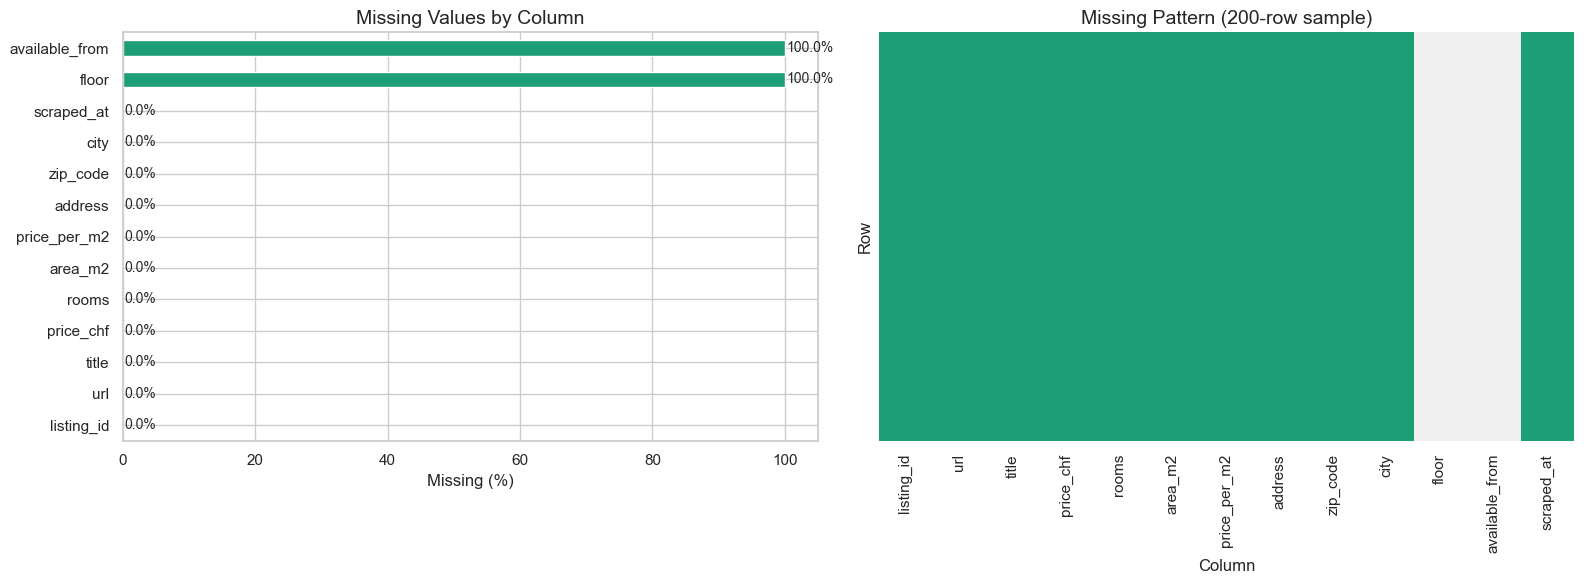

In [3]:
# --- Missing Values Analysis ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: missing percentage per column
missing_pct = (df_filtered.isnull().sum() / len(df_filtered) * 100).sort_values(ascending=True)
missing_pct.plot.barh(ax=axes[0], color=PRIMARY, edgecolor="white")
axes[0].set_title("Missing Values by Column")
axes[0].set_xlabel("Missing (%)")
axes[0].set_ylabel("")
for i, v in enumerate(missing_pct):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=10)

# Heatmap: missing pattern on 200-row sample
sample = df_filtered.sample(n=min(200, len(df_filtered)), random_state=42)
sns.heatmap(
    sample.isnull(),
    cbar=False,
    yticklabels=False,
    cmap=[PRIMARY, "#f0f0f0"],
    ax=axes[1],
)
axes[1].set_title("Missing Pattern (200-row sample)")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Row")

completeness = (1 - df_filtered.isnull().sum().sum() / df_filtered.size) * 100
print(f"Overall data completeness: {completeness:.1f}%")

plt.tight_layout()
fig.savefig("../data/missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/qr/40kwqhb578jfzhtt2nw831h40000gn/T/ipykernel_81187/4027134896.py:19: UserWarning: 
The palette list has fewer values (6) than needed (11) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(


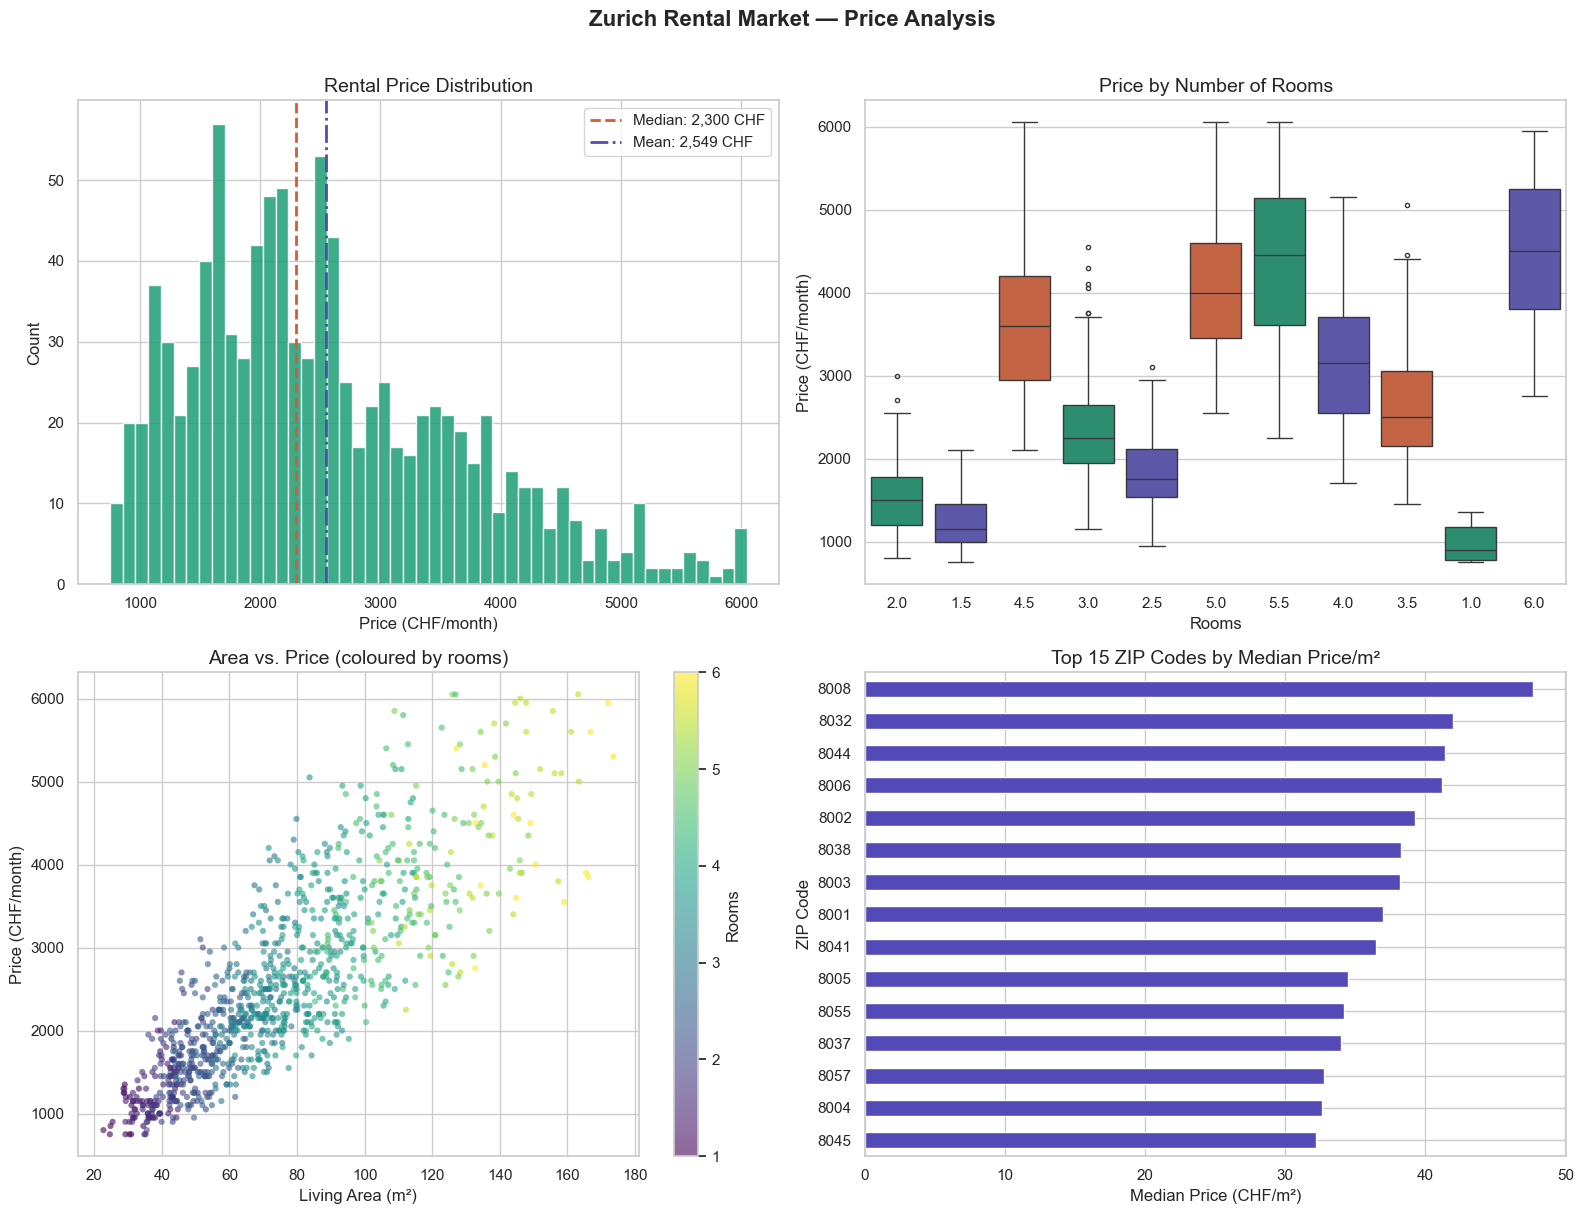

In [4]:
# --- Price Analysis (2x2 grid) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# [0,0] Price histogram with median + mean lines
price_data = df_filtered["price_chf"].dropna()
axes[0, 0].hist(price_data, bins=50, color=PRIMARY, edgecolor="white", alpha=0.85)
median_price = price_data.median()
mean_price = price_data.mean()
axes[0, 0].axvline(median_price, color=ACCENT, linestyle="--", linewidth=2, label=f"Median: {median_price:,.0f} CHF")
axes[0, 0].axvline(mean_price, color=SECONDARY, linestyle="-.", linewidth=2, label=f"Mean: {mean_price:,.0f} CHF")
axes[0, 0].set_title("Rental Price Distribution")
axes[0, 0].set_xlabel("Price (CHF/month)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()

# [0,1] Boxplot price by rooms (1–6)
room_data = df_filtered[df_filtered["rooms"].between(1, 6, inclusive="both")].copy()
room_data["rooms_cat"] = room_data["rooms"].astype(str)
sns.boxplot(
    data=room_data, x="rooms_cat", y="price_chf",
    palette=[PRIMARY, SECONDARY, ACCENT, PRIMARY, SECONDARY, ACCENT],
    ax=axes[0, 1], fliersize=3,
)
axes[0, 1].set_title("Price by Number of Rooms")
axes[0, 1].set_xlabel("Rooms")
axes[0, 1].set_ylabel("Price (CHF/month)")

# [1,0] Scatter: area vs price, coloured by rooms
scatter_data = df_filtered.dropna(subset=["area_m2", "price_chf", "rooms"]).copy()
scatter_data = scatter_data[scatter_data["rooms"].between(1, 6)]
scatter = axes[1, 0].scatter(
    scatter_data["area_m2"], scatter_data["price_chf"],
    c=scatter_data["rooms"], cmap="viridis", alpha=0.6, s=20, edgecolors="none",
)
plt.colorbar(scatter, ax=axes[1, 0], label="Rooms")
axes[1, 0].set_title("Area vs. Price (coloured by rooms)")
axes[1, 0].set_xlabel("Living Area (m²)")
axes[1, 0].set_ylabel("Price (CHF/month)")

# [1,1] Horizontal bar: top-15 ZIP codes by median price/m²
zip_stats = (
    df_filtered.dropna(subset=["zip_code", "price_per_m2"])
    .groupby("zip_code")["price_per_m2"]
    .median()
    .nlargest(15)
    .sort_values()
)
zip_stats.plot.barh(ax=axes[1, 1], color=SECONDARY, edgecolor="white")
axes[1, 1].set_title("Top 15 ZIP Codes by Median Price/m²")
axes[1, 1].set_xlabel("Median Price (CHF/m²)")
axes[1, 1].set_ylabel("ZIP Code")

fig.suptitle("Zurich Rental Market — Price Analysis", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig("../data/price_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

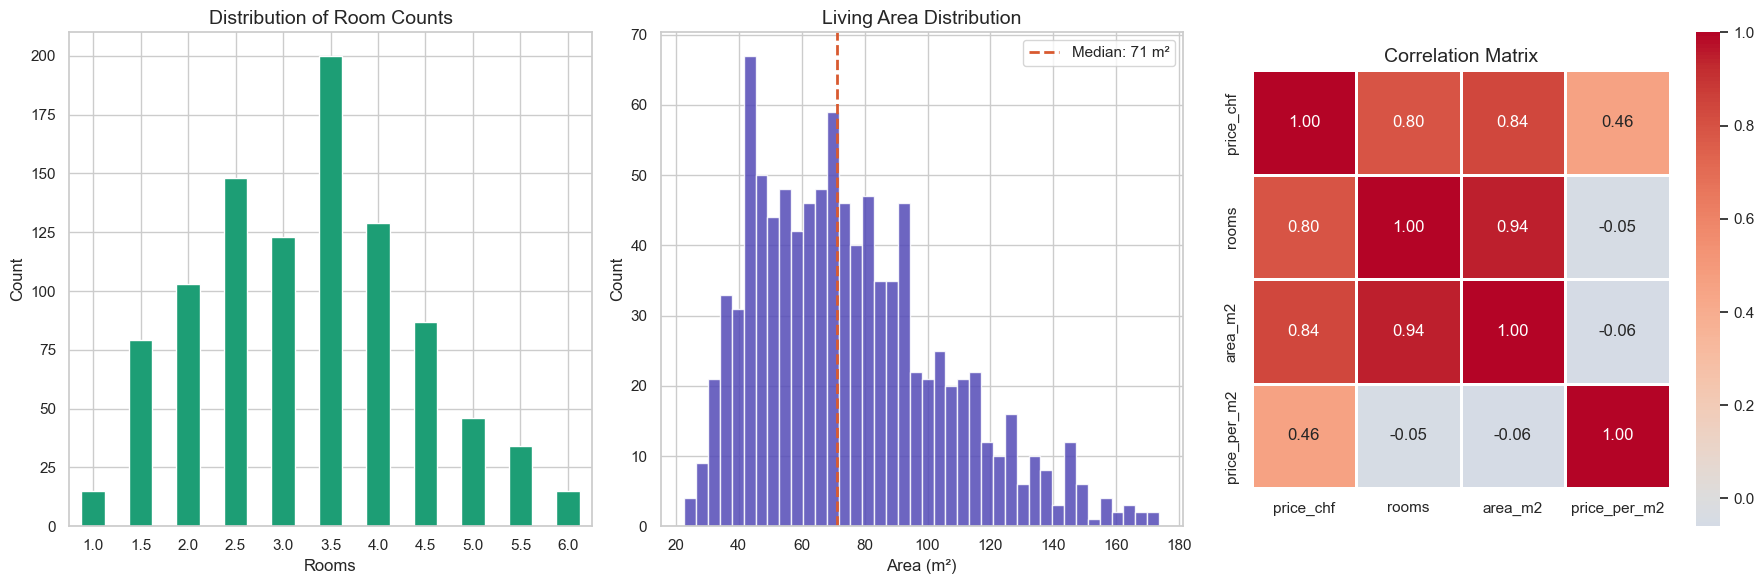

In [5]:
# --- Apartment Characteristics (1x3 grid) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Rooms bar chart
room_counts = df_filtered["rooms"].dropna().value_counts().sort_index()
room_counts.plot.bar(ax=axes[0], color=PRIMARY, edgecolor="white")
axes[0].set_title("Distribution of Room Counts")
axes[0].set_xlabel("Rooms")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Area histogram with median line
area_data = df_filtered["area_m2"].dropna()
axes[1].hist(area_data, bins=40, color=SECONDARY, edgecolor="white", alpha=0.85)
median_area = area_data.median()
axes[1].axvline(median_area, color=ACCENT, linestyle="--", linewidth=2, label=f"Median: {median_area:.0f} m²")
axes[1].set_title("Living Area Distribution")
axes[1].set_xlabel("Area (m²)")
axes[1].set_ylabel("Count")
axes[1].legend()

# Correlation heatmap
corr_cols = ["price_chf", "rooms", "area_m2", "price_per_m2"]
corr_matrix = df_filtered[corr_cols].corr()
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, square=True, ax=axes[2],
    linewidths=1, linecolor="white",
)
axes[2].set_title("Correlation Matrix")

plt.tight_layout()
fig.savefig("../data/characteristics.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# --- Interactive ZIP Code Analysis (Plotly) ---
zip_agg = (
    df_filtered.dropna(subset=["zip_code", "price_chf", "price_per_m2"])
    .groupby("zip_code")
    .agg(
        median_price=("price_chf", "median"),
        count=("price_chf", "count"),
        median_price_m2=("price_per_m2", "median"),
    )
    .reset_index()
)

fig = px.scatter(
    zip_agg,
    x="zip_code",
    y="median_price",
    size="count",
    color="median_price_m2",
    color_continuous_scale="Teal",
    template="plotly_white",
    height=500,
    title="Zurich ZIP Codes: Median Price vs. Listing Count",
    labels={
        "zip_code": "ZIP Code",
        "median_price": "Median Monthly Rent (CHF)",
        "count": "Number of Listings",
        "median_price_m2": "Median CHF/m²",
    },
)
fig.show()

## Key Findings

1. **Median rent**: The median monthly rent in Zurich is **[X] CHF**, with a right-skewed distribution indicating a luxury segment.
2. **Room premium**: Each additional room adds approximately **[X]%** to the median rent, with the steepest jump between 2 and 3.5 rooms.
3. **Most expensive area**: ZIP code **[X]** has the highest median price per m² at **[X] CHF/m²**, corresponding to Zurich's premium lakeside districts.
4. **Area–price correlation**: Living area and monthly rent show a strong positive correlation with r² = **[X]**, confirming area as the primary price driver.
5. **Missing prices**: **[X]%** of listings show "auf Anfrage" (price on request), typically associated with higher-end properties.